In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load SAM model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

sam = sam_model_registry["vit_b"](checkpoint=r"..\checkpoints\sam_vit_b.pth")
sam.to(device=device)
print("SAM loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Using device: cpu
SAM loaded successfully


Image shape: (1705, 2450, 3)


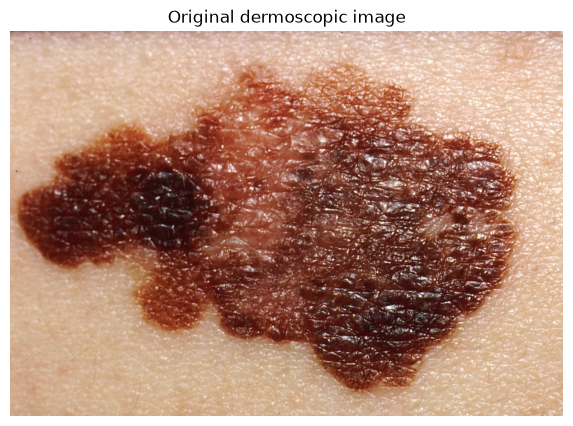

In [2]:
import os

# Pick any image from HAM10000
test_image_path = r"..\data\raw\HAM10000_images_part_1\ISIC_0024306.jpg"
# If that doesn't exist, list available images and pick one:
if not os.path.exists(test_image_path):
    files = os.listdir(r"..\data\raw\HAM10000_images_part_1")
    print("First 5 files:", files[:5])

image = np.array(Image.open(test_image_path).convert("RGB"))
print("Image shape:", image.shape)    # (450, 600, 3) — original HAM10000 size

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title("Original dermoscopic image")
plt.axis('off')
plt.show()

In [3]:
# SamAutomaticMaskGenerator finds ALL segments in the image
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,         # density of prompt points
    pred_iou_thresh=0.88,       # minimum quality threshold
    stability_score_thresh=0.95,
    min_mask_region_area=500,   # ignore very small segments (hair strands)
)

print("Running SAM... (takes ~10 seconds on CPU, ~2 seconds on GPU)")
masks = mask_generator.generate(image)
print(f"Found {len(masks)} segments")

# Each mask has: segmentation, area, bbox, predicted_iou, stability_score
print("\nLargest mask:")
largest = sorted(masks, key=lambda x: x['area'], reverse=True)[0]
print(f"  Area: {largest['area']} pixels")
print(f"  IoU:  {largest['predicted_iou']:.3f}")
print(f"  Bbox: {largest['bbox']}")    # [x, y, width, height]

Running SAM... (takes ~10 seconds on CPU, ~2 seconds on GPU)
Found 2 segments

Largest mask:
  Area: 2123672 pixels
  IoU:  1.012
  Bbox: [0, 7, 2449, 1691]


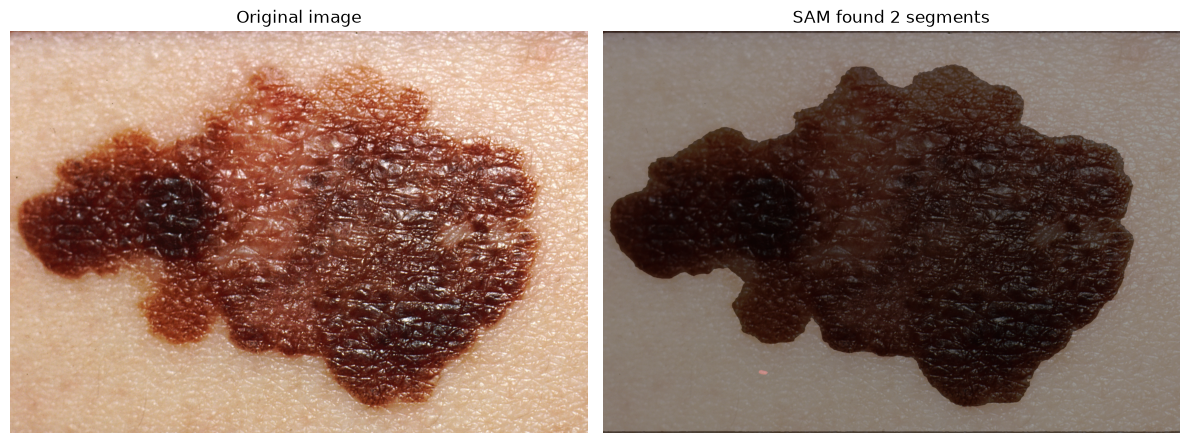

In [4]:
def show_all_masks(image, masks):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis('off')
    
    # Overlay all masks with different colours
    overlay = image.copy()
    colours = plt.cm.Set1(np.linspace(0, 1, len(masks)))
    
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    for i, mask_data in enumerate(masks):
        mask = mask_data['segmentation']
        colour = np.array(colours[i][:3])
        coloured_mask = np.zeros_like(image, dtype=float)
        coloured_mask[mask] = colour
        plt.imshow(coloured_mask, alpha=0.4)
    
    plt.title(f"SAM found {len(masks)} segments")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_all_masks(image, masks)

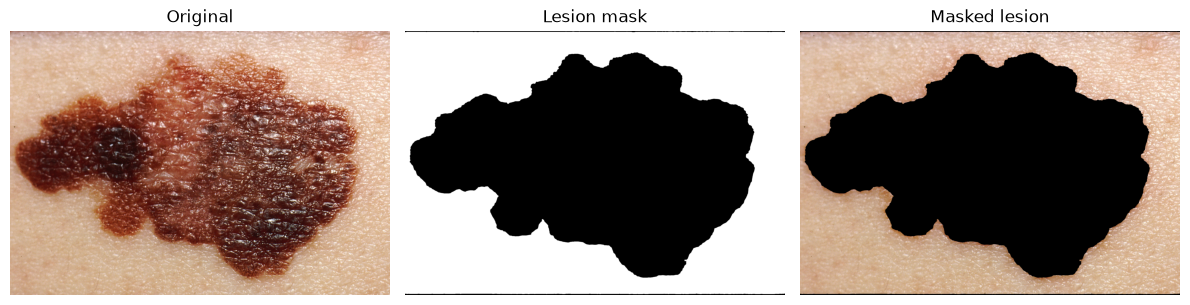

In [5]:
def get_lesion_mask(masks, image_shape):
    """
    Strategy: the lesion is usually the largest segment
    near the centre of the image.
    """
    h, w = image_shape[:2]
    centre_y, centre_x = h // 2, w // 2
    
    best_mask = None
    best_score = -1
    
    for mask_data in masks:
        seg = mask_data['segmentation']
        area = mask_data['area']
        
        # Find centre of this segment
        ys, xs = np.where(seg)
        if len(ys) == 0:
            continue
        seg_cy = ys.mean()
        seg_cx = xs.mean()
        
        # Distance from image centre
        dist = ((seg_cy - centre_y)**2 + (seg_cx - centre_x)**2)**0.5
        max_dist = (h**2 + w**2)**0.5
        
        # Score: larger area + closer to centre = better
        score = (area / (h * w)) - 0.3 * (dist / max_dist)
        
        if score > best_score:
            best_score = score
            best_mask = seg
    
    return best_mask

lesion_mask = get_lesion_mask(masks, image.shape)

# Apply mask — set everything outside lesion to black
masked_image = image.copy()
masked_image[~lesion_mask] = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(lesion_mask, cmap='gray')
plt.title("Lesion mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_image)
plt.title("Masked lesion")
plt.axis('off')

plt.tight_layout()
plt.show()

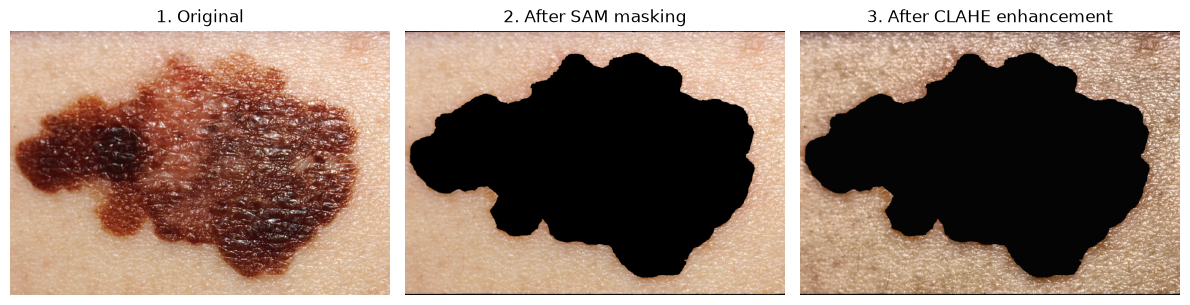

SAM + CLAHE pipeline working ✅
This is what every image will look like before going into the model


In [6]:
import cv2

def apply_clahe(image_rgb, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization).
    Works on LAB colour space to enhance contrast without changing hue.
    """
    # Convert RGB → LAB (L=lightness, A=green-red, B=blue-yellow)
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE only to L channel (lightness)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced

# Apply CLAHE to masked lesion only
clahe_image = apply_clahe(masked_image)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(masked_image)
plt.title("2. After SAM masking")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_image)
plt.title("3. After CLAHE enhancement")
plt.axis('off')

plt.tight_layout()
plt.savefig(r"sam_clahe_pipeline.png")
plt.show()

print("SAM + CLAHE pipeline working \u2705")
print("This is what every image will look like before going into the model")